# Práctica 2: Redes neuronales
# Inteligencia Artificial
# Grado en Ingeniería Informática - Ingeniería del Software
# Universidad de Sevilla

[Keras](https://keras.io/) es una biblioteca de Python que proporciona una interfaz amigable, modular y extensible para experimentar con redes neuronales. Esta práctica presenta una introducción a esa biblioteca, mostrando cómo resolver determinadas tareas de aprendizaje supervisado mediante la construcción de redes neuronales con alimentación hacia adelante.

En esta práctica también se hará uso de las bibliotecas NumPy, Pandas y scikit-learn.

El entrenamiento de las redes neuronales es un proceso computacionalmente costoso. Keras trata de reducir ese coste computacional mediante la aplicación de diferentes técnicas, como por ejemplo apoyándose en el uso de tarjetas gráficas para paralelizar los cálculos. Cuando no es posible usar alguna de esas técnicas (si el ordenador que ejecutará el código no dispone de ninguna GPU, entonces es evidente que Keras no podrá usarlas) emite un aviso informando de ello. En esta práctica ocultaremos todos los avisos de ese tipo.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

Trabajar con redes neuronales implica el manejo de números [pseudoaleatorios](https://es.wikipedia.org/wiki/N%C3%BAmero_pseudoaleatorio). Para que este documento sea reproducible es necesario, por tanto, establecer semillas iniciales para los generadores de esos números.

In [2]:
from keras.utils import set_random_seed

set_random_seed(394867)

In [5]:
%pip install keras tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


## Predicción del rendimiento y las emisiones de una turbina de gas

El fichero `gas_turbine.csv` contiene las siguientes medidas, agregadas por hora y tomadas desde el 1 de enero de 2011 hasta el 31 de diciembre de 2015, de una turbina de gas localizada en la región noroccidental de Turquía:

- AT: temperatura ambiental, en grados centígrados.
- AP: presión ambiental, en milibares.
- AH: humedad ambiental, en porcentaje.
- AFDP: diferencia de presión en el filtro de aire, en milibares.
- GTEP: presión de escape de la turbina de gas, en milibares.
- TIT: temperatura de entrada de la turbina, en grados centígrados.
- TAT: temperatura de salida de la turbina, en grados centígrados.
- CDP: presión de descarga del compresor, en milibares.
- TEY: rendimiento energético de la turbina, en megavatios por hora.
- CO: emisiones de monóxido de carbono, en miligramos por metro cúbico.
- NOX: emisiones de óxidos de nitrógeno, en miligramos por metro cúbico.

In [1]:
import pandas as pd

In [4]:
gas_turbine = pd.read_csv('gas_turbine.csv')
gas_turbine.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,CDP,TEY,CO,NOX
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,11.898,134.67,0.32663,81.952
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,11.892,134.67,0.44784,82.377
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,12.042,135.10,0.45144,83.776
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,11.990,135.03,0.23107,82.505
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,11.910,134.67,0.26747,82.028


El conjunto de datos contiene 36733 ejemplos y 11 atributos.

In [5]:
gas_turbine.shape

(36733, 11)

Se plantea el problema de predecir **a la vez** el rendimiento energético de la turbina (TEY), las emisiones de monóxido de carbono (CO) y las emisiones de óxidos de nitrógeno (NOX) a partir de las medidas ambientales (AT, AP y AH) y de las medidas de los sensores de la turbina (AFDP, GTEP, TIT, TAT, CDP). Obsérvese que se trata de un problema de regresión múltiple, puesto que los atributos objetivo son variables continuas.

En primer lugar, separamos los datos de los atributos de los ejemplos y los de los atributos objetivo.

In [6]:
atributos = gas_turbine.loc[:, 'AT':'CDP']
atributos.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,CDP
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,11.898
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,11.892
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,12.042
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,11.990
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,11.910


In [7]:
objetivo = gas_turbine.loc[:, 'TEY':'NOX']
objetivo.head()

,TEY,CO,NOX
0,134.67,0.32663,81.952
1,134.67,0.44784,82.377
2,135.10,0.45144,83.776
3,135.03,0.23107,82.505
4,134.67,0.26747,82.028


Puesto que hay una cantidad suficiente de ejemplos, podemos usar validación por retención para evaluar las redes construidas para abordar la tarea planteada. Para ello dividimos el conjunto de ejemplos en un subconjunto de entrenamiento y un subconjunto de prueba.

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
(atributos_entrenamiento, atributos_prueba,
 objetivo_entrenamiento, objetivo_prueba) = train_test_split(
    atributos, objetivo,
    test_size=.2
)

A la hora de utilizar Keras para construir una red neuronal, hay que tener en cuenta las siguientes características generales de esa biblioteca:

- La biblioteca está organizada en módulos, siendo habitual importar únicamente las funciones y clases concretas que se vayan a usar, en lugar de importar toda la biblioteca o un módulo completo. Para ello se usarán expresiones de la forma `from keras import función_o_Clase`.
- La biblioteca admite dos aproximaciones a la hora de construir una red neuronal: el modelo funcional, más complejo, pero más flexible, y el modelo secuencial, más rígido, pero más simple. En esta práctica usaremos el modelo secuencial.

En el modelo secuencial, implementado por la clase `Sequential`, se construye una red neuronal añadiendo las capas una a una, comenzando con la capa de entrada, continuando con las capas ocultas y  y finalizando con la capa de salida.

La capa de entrada se construye como instancia de la clase `Input`, indicando la forma de la entrada, que puede ser un array con cualquier número de dimensiones. En nuestro caso la entrada será un array unidimensional con los valores de los atributos, pero podría ser por ejemplo una imagen bidimensional, etcétera.

Para construir una red neuronal con alimentación hacia adelante, en el que las capas están totalmente conectadas, hay que añadir instancias de la clase `Dense` del módulo `layers`, indicando la cantidad de neuronas y la función de activación (por defecto, la identidad).

Por ejemplo, podemos construir una red neuronal con ocho neuronas de entrada, una por cada atributo, y tres neuronas de salida, una por cada atributo objetivo, de la siguiente manera:

In [11]:
from keras import Sequential, Input
from keras.layers import Dense

In [12]:
red_turbina = Sequential()
red_turbina.add(Input(shape=(8,)))
red_turbina.add(Dense(3))

El método `summary` nos muestra la estructura de la red, indicando para cada capa la forma de su salida y cuántos parámetros posee. La capa de entrada no se muestra, ya que no posee parámetros. La primera dimensión en la forma de la salida de cada capa indica el tamaño de los minilotes (de los que hablaremos posteriormente) y se usa `None` para indicar que su valor no está fijado.

In [13]:
red_turbina.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

Se observa cómo la red neuronal posee una única capa (aparte de la de entrada) que proporciona como salida un array bidimensional `None x 3` (es decir, para cada ejemplo proporciona tres valores) y 27 parámetros (el peso de la conexión de cada entrada con las neuronas de la capa más los sesgos de las neuronas) entrenables (la red los aprenderá mediante el algoritmo de entrenamiento).

Los pesos y sesgos de la red se guardan en el atributo `weights`.

In [14]:
red_turbina.weights

[<Variable path=sequential/dense/kernel, shape=(8, 3), dtype=float32, value=[[ 0.2611305   0.50001127  0.068766  ]
  [ 0.71479243  0.42871457 -0.5764321 ]
  [-0.38990813 -0.07370108 -0.7160102 ]
  [ 0.68229455  0.5099568   0.48986048]
  [-0.07705003 -0.3105778   0.72428125]
  [ 0.6422098  -0.17716336  0.11557788]
  [ 0.02198672 -0.6555279  -0.4149131 ]
  [-0.43342215 -0.39902788 -0.3140125 ]]>,
 <Variable path=sequential/dense/bias, shape=(3,), dtype=float32, value=[0. 0. 0.]>]

Si le pedimos a la red que prediga el rendimiento energético y las emisiones de los cinco primeros ejemplos del conjunto de datos, se obtendrán valores muy distintos de los correctos mostrados anteriormente, ya que todavía no se ha entrenado la red.

In [15]:
red_turbina.predict(atributos[0:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


array([[1401.8241 , -130.37666, -734.01605],
       [1401.1848 , -130.85464, -734.33026],
       [1401.112  , -131.28055, -734.8856 ],
       [1400.8008 , -131.38898, -735.28503],
       [1400.1869 , -131.33437, -734.7865 ]], dtype=float32)

Para entrenar una red neuronal hay que compilarla primero, estableciendo el [algoritmo de aprendizaje](https://keras.io/api/optimizers/) (*optimizer*) y la [función de pérdida](https://keras.io/api/losses/) (*loss*) a minimizar. Para una tarea de regresión es habitual utilizar el error cuadrático medio como función de pérdida (como la red tiene tres neuronas de salida, para cada ejemplo cada una de ellas comete un error; por defecto estos errores se agregan mediante la media para obtener el error final cometido para cada ejemplo). Como algoritmo de entrenamiento usaremos descenso estocástico por el gradiente (*stochastic gradient descent*, SGD).

In [16]:
red_turbina.compile(optimizer='SGD', loss='mean_squared_error')

Por defecto se usa un factor de aprendizaje igual a 0.01. Solo falta, entonces, proporcionar los ejemplos de entrenamiento junto con la salida esperada para cada uno de ellos, el tamaño de los minilotes y el número de épocas a entrenar.

In [17]:
red_turbina.fit(atributos_entrenamiento, objetivo_entrenamiento,
                batch_size=256, epochs=10)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan         
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - loss: nan
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - loss: nan
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan  
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan  
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: nan
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - loss: nan
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan  
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan  


Motivos comunes de por qué sale nan:
- Los datos de entrada contienen un NaN
- Los datos no están escalados (toman valores demasiado grandes). Keras espera valores alrededor de 0-1.
- Tasa de aprendizaje demasiado grande (oscila en valores en donde no está bien definida la función). Bajar la tasa de aprendizaje (valor del salto del algoritmo).
- Errores matemáticos  como log(0), 0/0... al usar por ejemplo crossentropy + Id.

Como se puede observar, el entrenamiento ha fallado, ya que desde la primera época se obtiene `nan` (*not a number*) como valor de la función de pérdida. Los motivos de que se produzca esta circunstancia pueden ser múltiples y, a veces, difíciles de determinar.

Una primera comprobación a efectuar es cerciorarnos de que no hay ningún valor perdido en el conjunto de datos que pueda dar lugar a `nan` al realizar los cálculos de entrenamiento de la red. Sin embargo, este no es el problema en nuestro caso.

In [18]:
gas_turbine.isna().any()

AT      False
AP      False
AH      False
AFDP    False
GTEP    False
TIT     False
TAT     False
CDP     False
TEY     False
CO      False
NOX     False
dtype: bool

La raíz del problema se encuentra en que la salida de la capa de entrada son los valores en bruto de los atributos, lo que conduce a una _explosión del gradiente_: la magnitud de los gradientes de los pesos de la capa de salida resulta demasiado grande, ocasionando un crecimiento exponencial de los pesos que lleva rápidamente a que se produzca un desbordamiento numérico en el cálculo de la salida de la red. Una recomendación para tratar de evitar esa explosión del gradiente es hacer que las salidas de las neuronas sean cercanas a cero en general.

En el caso que nos ocupa, una solución al problema es introducir tras la capa de entrada una capa de normalización como por ejemplo la disponible en Keras para tipificar las variables (a cada variable se le resta su media y se divide por su desviación típica). Los parámetros de esta capa de normalización deben ajustarse a partir únicamente de los datos de entrenamiento (que deben proporcionarse como un array de Numpy), lo que se hace mediante el método `adapt`.

In [19]:
from keras.layers import Normalization

In [20]:
normalizador = Normalization()
normalizador.adapt(atributos_entrenamiento.to_numpy())

Podemos comprobar cómo todos los atributos de entrenamiento tienen media y varianza aproximadamente 0 y 1, respectivamente, al ser normalizados.

In [21]:
import numpy as np

In [22]:
np.mean(normalizador(atributos_entrenamiento), axis=0)

array([ 1.0055267e-07, -4.1077114e-06,  1.8205927e-07, -8.1522828e-08,
       -1.5140606e-07, -5.7610384e-07,  3.8926541e-06, -3.2736310e-08],
      dtype=float32)

In [23]:
np.var(normalizador(atributos_entrenamiento), axis=0)

array([1.0000011 , 0.99997115, 0.9999968 , 0.99999416, 0.9999995 ,
       0.9999886 , 1.0000162 , 0.99999785], dtype=float32)

Al introducir en la red esa capa de normalización justo tras la capa de entrada, todos los datos que se proporcionen como entrada a la red se tipificarán usando las medias y desviaciones típicas calculadas.

In [24]:
red_turbina = Sequential()
red_turbina.add(Input(shape=(8,)))
red_turbina.add(normalizador)
red_turbina.add(Dense(3))

Se puede comprobar que los parámetros de esa capa de normalización no son entrenables, es decir, no se modificarán al aplicar a la red el algoritmo de descenso estocástico por el gradiente (la capa de normalización tiene 17 parámetros en total porque guarda la media y la desviación típica de cada uno de los ocho atributos y, además, la cantidad total de ejemplos a partir de los cuales se han calculado).

In [25]:
red_turbina.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44 (180.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 17 (72.00 B)

Como se ha vuelto a construir la red desde cero, también hay que volverla a compilar.

In [26]:
red_turbina.compile(optimizer='SGD', loss='mean_squared_error')

Ahora la red ya entrena sin problema.

In [27]:
red_turbina.fit(atributos_entrenamiento, objetivo_entrenamiento,
                batch_size=256, epochs=10)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3845.2463  
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 849.7406 
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - loss: 207.5785
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - loss: 68.8169
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - loss: 38.4281
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 31.4869
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 29.6912
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - loss: 29.0711
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 28.7496  
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 28.5237  


Para comprobar el comportamiento de la red sobre los datos de prueba basta usar el método `evaluate`.

In [28]:
red_turbina.evaluate(atributos_prueba, objetivo_prueba)

230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - loss: 27.9220


27.92201042175293

Una forma de tratar de mejorar el rendimiento de la red neuronal es aumentar el número de épocas de entrenamiento. Esto, aparte del obvio coste en tiempo que supone, no garantiza que el algoritmo de entrenamiento no se quede atascado en un mínimo local de la función de pérdida, sin llegar a aproximarse nunca al mínimo global.

Otra vía para conseguir una red neuronal con mejor rendimiento es modificar la arquitectura de la misma. Por ejemplo, en el caso que nos ocupa, podemos probar a incluir una capa oculta de la que se ha elegido, de forma arbitraria, que tenga 10 neuronas.

In [29]:
red_turbina = Sequential()
red_turbina.add(Input(shape=(8,)))
red_turbina.add(normalizador)
red_turbina.add(Dense(10))
red_turbina.add(Dense(3))

Esta red tiene 123 parámetros entrenables, que provienen de los 8x10 pesos más 10 sesgos de las neuronas de la capa oculta junto con los 10x3 pesos más 3 sesgos de las neuronas de la capa de salida. También tiene 17 parámetros no entrenables, que provienen de la capa de normalización.

In [30]:
red_turbina.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140 (564.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 17 (72.00 B)

Al compilar la red se puede indicar también que, aparte de la función de pérdida, se calculen otras [métricas](https://keras.io/api/metrics/) adecuadas. Por ejemplo, el error absoluto medio (es decir, la media de las diferencias en valor absoluto entre los valores predichos y los valores correctos) es una métrica adecuada para una tarea de regresión.

In [31]:
red_turbina.compile(optimizer='SGD', loss='mean_squared_error',
                    metrics=['mean_absolute_error'])

In [32]:
red_turbina.fit(atributos_entrenamiento, objetivo_entrenamiento,
                batch_size=256, epochs=10)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mean_absolute_error: nan           
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mean_absolute_error: nan
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mean_absolute_error: nan
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mean_absolute_error: nan
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - mean_absolute_error: nan
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mean_absolute_error: nan  
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mean_absolute_error: nan  
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mean_absolute_error: nan
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mean_absolute_error: nan
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - mean_absolute_error: nan  


De nuevo se han producido desbordamientos en el cálculo de la función de pérdida. En este caso es debido a que las neuronas de la capa oculta tienen como función de activación a la función identidad (la función de activación por defecto). Por lo tanto, aunque ellas sí reciben las entradas normalizadas, los valores que devuelven, y que son las que recibe la neurona de la capa de salida, pueden alejarse bastante del valor cero. Si establecemos como función de activación de las neuronas de la capa oculta a la función sigmoide, esta normalizará al intervalo (0, 1) los valores que devuelven esas neuronas y la red se podrá entrenar sin problema.

In [33]:
red_turbina = Sequential()
red_turbina.add(Input(shape=(8,)))
red_turbina.add(normalizador)
red_turbina.add(Dense(10, activation='sigmoid'))
red_turbina.add(Dense(3))

Al compilar la red se pueden cambiar los parámetros de los distintos argumentos proporcionando, en lugar del nombre, una instancia de la clase que lo implementa. Por ejemplo, para establecer el factor de aprendizaje, en lugar de proporcionar el nombre `'SGD'` para indicar descenso estocástico por el gradiente como optimizador hay que proporcionar una instancia de la clase `SGD` que lo implementa.

In [34]:
from keras.optimizers import SGD

In [35]:
red_turbina.compile(optimizer=SGD(learning_rate=0.02), loss='mean_squared_error',
                    metrics=['mean_absolute_error'])

In [36]:
red_turbina.fit(atributos_entrenamiento, objetivo_entrenamiento,
               batch_size=256, epochs=10)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 425.8903 - mean_absolute_error: 9.5827   
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 53.2946 - mean_absolute_error: 4.4371  
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 41.7283 - mean_absolute_error: 3.8555  
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 34.3971 - mean_absolute_error: 3.4610  
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 29.8894 - mean_absolute_error: 3.1984  
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 26.9890 - mean_absolute_error: 3.0226
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.9349 - mean_absolute_error: 2.9061
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 23.3404 - mean_absolute_error: 2.8206  
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 22.0465 - mean_absolute_error: 2.7484
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.9944 - mean_absolute_error: 2.6844


In [37]:
red_turbina.evaluate(atributos_prueba, objetivo_prueba)

230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 19.8283 - mean_absolute_error: 2.6396  


[19.828338623046875, 2.639629364013672]

Se obtiene un error sobre el conjunto de prueba menor que el obtenido con la red sin capa oculta.

## Predicción de situación de riesgo de sufrir un accidente cerebrovascular

 El fichero `stroke.csv` contiene un conjunto de datos de una serie de pacientes, indicando, para cada uno de ellos, si ha sufrido o no un accidente cerebrovascular y los valores de una serie de factores de riesgo como el sexo, la edad, diversas enfermedades y el tabaquismo.

In [38]:
stroke = pd.read_csv('stroke.csv')
stroke.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
1,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes
2,Female,49.0,No,No,Yes,Private,Urban,171.23,34.4,smokes,Yes
3,Female,79.0,Yes,No,Yes,Self-employed,Rural,174.12,24.0,never smoked,Yes
4,Male,81.0,No,No,Yes,Private,Urban,186.21,29.0,formerly smoked,Yes


El objetivo es construir una red neuronal que prediga, de la mejor manera posible, si un paciente está o no en riesgo de sufrir un accidente cerebrovascular a partir de los factores incluidos en el conjunto de datos:

- Sexo del paciente (`gender`): atributo discreto con posibles valores `Female` y `Male`.
- Edad del paciente (`age`): atributo continuo.
- ¿El paciente sufre de hipertensión? (`hypertension`): atributo discreto con posibles valores `No` y `Yes`.
- ¿El paciente está enfermo del corazón? (`heart_disease`): atributo discreto con posibles valores `No` y `Yes`.
- ¿El paciente está o ha estado casado? (`ever_married`): atributo discreto con posibles valores `No` y `Yes`.
- Tipo de trabajo del paciente (`work_type`): atributo discreto con posibles valores `children`, `Govt_jov`, `Never_worked`, `Private` y `Self-employed`.
- Tipo de domicilio del paciente (`Residence_type`): atributo discreto con posibles valores `Rural` y `Urban`.
- Nivel medio de glucosa en sangre del paciente (`avg_glucose_level`): atributo continuo.
- Índice de masa corporal del paciente (`bmi`): atributo continuo.
- Estado de tabaquismo del paciente (`smoking_status`): atributo discreto con posibles valores `formerly smoked`, `never smoked` y `smokes`.

El atributo objetivo es `stroke`, que es un atributo discreto con posibles valores `No` y `Yes` indicando si el paciente ha sufrido o no un accidente cerebrovascular. Se trata, por tanto, de realizar una **tarea de clasificación binaria**.

El conjunto de datos contiene 3425 ejemplos y 11 atributos.

In [39]:
stroke.shape

(3425, 11)

En primer lugar, comprobamos que no hay ningún valor perdido en el conjunto de datos.

In [40]:
stroke.isna().any()

gender               False
age                  False
hypertension         False
heart_disease        False
ever_married         False
work_type            False
Residence_type       False
avg_glucose_level    False
bmi                  False
smoking_status       False
stroke               False
dtype: bool

Ahora separamos los datos de los atributos de los ejemplos y los del atributo objetivo.

In [41]:
atributos_discretos = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                       'work_type', 'Residence_type', 'smoking_status']
atributos_continuos = ['age', 'avg_glucose_level', 'bmi']

In [42]:
atributos = stroke.loc[:, atributos_discretos + atributos_continuos]
atributos.head()

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,age,avg_glucose_level,bmi
0,Male,No,Yes,Yes,Private,Urban,formerly smoked,67.0,228.69,36.6
1,Male,No,Yes,Yes,Private,Rural,never smoked,80.0,105.92,32.5
2,Female,No,No,Yes,Private,Urban,smokes,49.0,171.23,34.4
3,Female,Yes,No,Yes,Self-employed,Rural,never smoked,79.0,174.12,24.0
4,Male,No,No,Yes,Private,Urban,formerly smoked,81.0,186.21,29.0


Al entrenar las redes neuronales estas esperan recibir los valores objetivos en un array tal que el primer eje corresponda a cada ejemplo y los restantes ejes a los valores correspondientes. Por otra parte, el atributo objetivo es una variable discreta con posibles valores No y Yes. Para poder comparar esos valores con las salidas de la red neuronal, que son siempre numéricas, debemos convertirlos a números: el valor No lo convertimos a 0 y el valor Yes a 1, ya que será esta última la que consideraremos como clase positiva. La función `label_binarize` de scikit-learn permite preprocesar el atributo objetivo para cumplir ambos requisitos

In [43]:
from sklearn.preprocessing import label_binarize

In [44]:
objetivo = label_binarize(stroke['stroke'],
                          classes = ['No', 'Yes'])
objetivo

array([[1],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]], shape=(3425, 1))

Aunque la cantidad de ejemplos es relativamente pequeña, usaremos validación por retención para evaluar las redes construidas para abordar la tarea planteada. Para ello dividimos el conjunto de ejemplos en un subconjunto de entrenamiento y un subconjunto de prueba.

In [45]:
(atributos_entrenamiento, atributos_prueba,
 objetivo_entrenamiento, objetivo_prueba) = train_test_split(
    atributos, objetivo,
    test_size=.2,
    stratify=objetivo
)

Las redes neuronales definen funciones de números reales, por lo que no podemos proporcionarles directamente los valores de los atributos discretos, ya que son cadenas. En consecuencia, debemos codificar numéricamente esos valores.

Para evitar el problema de la explosión del gradiente:

- Usamos una codificación _one-hot_ para los atributos discretos. De esta forma, cada categoría de cada atributo discreto se codificará mediante una variable binaria que, por tanto, solo tomará el valor 0 o el valor 1.
- Normalizamos los atributos continuos mediante tipificación, de tal forma que para cada uno de ellos resulte un conjunto de valores con media 0 y desviación típica 1.

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [47]:
preprocesador = ColumnTransformer(
    [('codificador', OneHotEncoder(), atributos_discretos),
     ('normalizador', StandardScaler(), atributos_continuos)]
)
atributos_entrenamiento_preprocesados = preprocesador.fit_transform(atributos_entrenamiento)

Nótese que por defecto el codificador _one-hot_ detecta automáticamente las categorías de las variables discretas al ajustarlo a los datos. En nuestro caso esto funciona porque, como se muestra a continuación, en el conjunto de entrenamiento están representadas todas las categorías (si no fuera así, habría que especificar las categorías mediante el argumento `categories` de `OneHotEncoder`).

In [48]:
atributos_entrenamiento[atributos_discretos].apply(lambda columna: columna.unique())

gender                                               [Male, Female]
hypertension                                              [No, Yes]
heart_disease                                             [Yes, No]
ever_married                                              [Yes, No]
work_type         [Private, Self-employed, Govt_job, children, N...
Residence_type                                       [Urban, Rural]
smoking_status              [formerly smoked, never smoked, smokes]
dtype: object

Tras preprocesar el conjunto de entrenamiento los ejemplos pasan a estar descritos por 21 atributos: un atributo binario por cada categoría de cada atributo discreto y un atributo continuo con media 0 y desviación típica 1 por cada atributo continuo.

In [49]:
atributos_entrenamiento_preprocesados.shape

(2740, 21)

In [50]:
atributos_entrenamiento_preprocesados[:5]

array([[ 0.        ,  1.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         1.        ,  0.        ,  0.        ,  0.98964855,  2.50932706,
         0.87212033],
       [ 1.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ,  1.67763953,  2.18382285,
         0.61085259],
       [ 1.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  0.        , -0.65094531, -0.65733996,
        -0.25545621],
       [ 0.        ,  1.        ,  1.        ,  0.        

Estamos ya en condiciones de entrenar una red que reciba los valores de esos 21 atributos (debe tener, entonces, 21 neuronas de entrada) y devuelva un valor en el intervalo (0, 1), representando la probabilidad de pertenencia a la clase positiva (en la capa de salida incluimos entonces una única neurona, con función de activación sigmoide). Se ha decidido también, de forma arbitraria, que la red tenga una capa oculta con 16 unidades lineales rectificadas.

In [51]:
red_stroke = Sequential()
red_stroke.add(Input(shape=(21,)))
red_stroke.add(Dense(16, activation='relu'))
red_stroke.add(Dense(1, activation='sigmoid'))

In [52]:
red_stroke.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

La función de pérdida a minimizar durante el entrenamiento de la red debe ser, en este caso, la entropía cruzada binaria. Por otra parte, estamos interesados en obtener una red con una alta sensibilidad, más que con una alta tasa de aciertos.

**Nota**: la métrica `BinaryAccuracy` calcula la tasa de acierto tras discretizar la salida de la red en función de un valor umbral que por defecto vale 0.5. Su uso puede indicarse mediante la cadena `'binary_accuracy'` porque también está implementada como función, según indica [este listado](https://www.tensorflow.org/api_docs/python/tf/keras/metrics#functions). No es el caso de la sensibilidad, por lo que esta métrica solo puede usarse proporcionando una instancia de la clase `Recall` que la implementa.

In [53]:
from keras.metrics import Recall

In [54]:
red_stroke.compile(optimizer='SGD', loss='binary_crossentropy',
                   metrics=['binary_accuracy', Recall()])

In [55]:
red_stroke.fit(atributos_entrenamiento_preprocesados, objetivo_entrenamiento,
               batch_size=256, epochs=10)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.3055 - loss: 0.8278 - recall: 0.9792  
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5036 - loss: 0.7194 - recall: 0.8819 
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6573 - loss: 0.6384 - recall: 0.6875 
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7788 - loss: 0.5749 - recall: 0.5625 
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8518 - loss: 0.5231 - recall: 0.3750 
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8942 - loss: 0.4798 - recall: 0.2917 
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9175 - loss: 0.4429 - recall: 0.1736 
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9288 - loss: 0.4111 - recall: 0.1458 
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9347 - loss: 0.3836 - recall: 0.0694 
Epoch 10/10
11/11 

Nótese cómo disminuye el error a medida que transcurren las épocas, aunque sin embargo eso se traduce en un modelo con cada vez mayor tasa de acierto, pero menor sensibilidad. Esto se debe a que el conjunto de datos está muy desequilibrado, lo que lleva a la red a aprender a clasificar siempre los ejemplos en la clase negativa.

Una manera de abordar el problema del desequilibrio de clases es ponderando la función de pérdida de tal manera que forcemos a la red a darle mayor importancia al error cometido para los ejemplos de la clase minoritaria que para los de la clase mayoritaria. Por ejemplo, si ponderamos con 1 para la clase mayoritaria y con 10 para la minoritaria, le estaremos indicando a la red neuronal que el error para un único ejemplo de la clase minoritaria debe contar como el error para diez ejemplos de la clase mayoritaria.

Es habitual ponderar las clases de forma inversamente proporcional a su frecuencia. Para calcular los pesos correspondientes a este criterio se puede usar la función `class_weight` de scikit-learn.

In [56]:
from sklearn.utils.class_weight import compute_class_weight

In [57]:
# El argumento classes indica las distintas clases
# El argumento y debe ser un array unidimensional de los valores
compute_class_weight('balanced',
                     classes=np.array([0, 1]),
                     y=objetivo.reshape(-1))

array([0.52773498, 9.51388889])

Ahora la red es capaz de aprender a clasificar correctamente los ejemplos positivos, aunque a costa de una menor tasa de acierto, ya que aumenta el número de falsos positivos.

In [58]:
red_stroke.fit(atributos_entrenamiento_preprocesados, objetivo_entrenamiento,
              batch_size=256, epochs=10, class_weight={0: 0.52773498, 1: 9.51388889})

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9409 - loss: 0.6943 - recall: 0.0556      
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9350 - loss: 0.6722 - recall: 0.0764     
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9255 - loss: 0.6535 - recall: 0.1597 
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9142 - loss: 0.6377 - recall: 0.2014 
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8993 - loss: 0.6236 - recall: 0.2778 
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8770 - loss: 0.6116 - recall: 0.3333 
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8551 - loss: 0.6012 - recall: 0.3750 
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8431 - loss: 0.5921 - recall: 0.4861 
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8270 - loss: 0.5843 - recall: 0.5347 
Epoch 10/1

A la hora de evaluar el rendimiento de la red sobre el conjunto de prueba, hay que tener en cuenta que la red espera recibir ya preprocesados los valores de los atributos.

In [59]:
atributos_prueba_preprocesados = preprocesador.transform(atributos_prueba)
red_stroke.evaluate(atributos_prueba_preprocesados, objetivo_prueba)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7883 - loss: 0.5090 - recall: 0.6944      


[0.5090487599372864, 0.7883211970329285, 0.6944444179534912]

## Predicción de dígitos escritos a mano

MNIST es un conjunto de imágenes de dígitos manuscritos en blanco y negro, normalizados a un tamaño de 28x28 píxeles y suavizados a una escala de grises. Este conjunto de datos está incluido en Keras y dispone de 60000 imágenes de entrenamiento y 10000 imágenes de prueba.

In [60]:
from keras.datasets import mnist

In [61]:
((atributos_entrenamiento, objetivo_entrenamiento),
 (atributos_prueba, objetivo_prueba)) = mnist.load_data()

In [62]:
(atributos_entrenamiento.shape, objetivo_entrenamiento.shape)

((60000, 28, 28), (60000,))

In [63]:
(atributos_prueba.shape, objetivo_prueba.shape)

((10000, 28, 28), (10000,))

Cada imagen es una matriz de 28 filas y 28 columnas cuyos elementos son números entre 0 y 255 que indican el nivel de gris del píxel correspondiente.

In [64]:
atributos_entrenamiento[0]  # Primera imagen de entrenamiento

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

Podemos representar la matriz de píxeles como una imagen mediante la biblioteca matplotlib.

In [65]:
import matplotlib.pyplot as plt

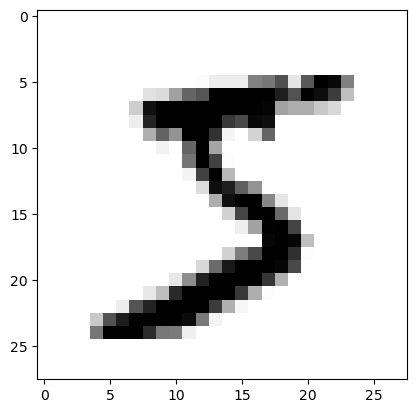

In [66]:
plt.imshow(atributos_entrenamiento[0], cmap=plt.cm.binary)

La primera imagen del conjunto de entrenamiento corresponde, entonces, al dígito 5.

In [67]:
objetivo_entrenamiento[0]

np.uint8(5)

El objetivo es aprender a predecir el dígito a partir de la imagen. Como hay diez dígitos distintos, se trata de una **tarea de clasificación multiclase**.

Para abordar la tarea mediante redes neuronales, lo adecuado es que estas tengan como capa de salida una capa con 10 neuronas y función de activación softmax. De esta forma, cada neurona de salida proporcionará la probabilidad de que la imagen sea de un determinado dígito.

Entonces, para poder comparar la salida de la red con la salida correcta, estas deben convertirse a una codificación _one-hot_, para lo que puede usarse el preprocesador `label_binarize` de scikit-learn o la función `to_categorical` de Keras.

In [68]:
from keras.utils import to_categorical

In [71]:
objetivo_entrenamiento = to_categorical(objetivo_entrenamiento, num_classes=10)
objetivo_entrenamiento[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [72]:
objetivo_prueba = to_categorical(objetivo_prueba, num_classes=10)

Como ya se ha comentado a lo largo de la práctica, es conveniente que los valores de entrada sean cercanos a 0, para evitar el problema de la explosión del gradiente. Como los píxeles contienen valores en el intervalo [0, 255], los normalizaremos al intervalo [0, 1] incluyendo en la red una capa de reescalado (capa `Rescaling`). Obsérvese que la inclusión de esa capa hace que no sea necesario preprocesar previamente el conjunto de datos, ya que es la propia red la que realiza la normalización al recibir los datos en bruto.

Por otra parte, también es necesario «aplanar» la imagen ya que, si no, los resultados de las distintas capas densas, incluida la de salida, serían bidimensionales y, por tanto, no comparables con los valores del atributo objetivo. Para ello incluiremos en la red una capa de aplanado (capa `Flatten`).

In [73]:
from keras.layers import Rescaling, Flatten

In [74]:
red_mnist = Sequential()
red_mnist.add(Input(shape=(28, 28)))
red_mnist.add(Rescaling(1 / 255))
red_mnist.add(Flatten())
red_mnist.add(Dense(32, activation='tanh'))
red_mnist.add(Dense(64, activation='tanh'))
red_mnist.add(Dense(128, activation='tanh'))
red_mnist.add(Dense(10, activation='softmax'))

In [75]:
red_mnist.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,842 (143.91 KB)

 Trainable params: 36,842 (143.91 KB)

 Non-trainable params: 0 (0.00 B)

Para una tarea de clasificación multiclase y una red neuronal con salida softmax, la función de pérdida adecuada a minimizar por el entrenamiento es la entropía cruzada categórica. Como métrica para evaluar el rendimiento del modelo consideraremos la tasa de acierto.

In [76]:
red_mnist.compile(optimizer='SGD', loss='categorical_crossentropy',
                  metrics=['categorical_accuracy'])

In [77]:
red_mnist.fit(atributos_entrenamiento, objetivo_entrenamiento,
              batch_size=1024, epochs=10)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.3144 - loss: 2.1043
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5894 - loss: 1.6811
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.6852 - loss: 1.3605
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.7401 - loss: 1.1401
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.7726 - loss: 0.9836
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.7950 - loss: 0.8698
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8115 - loss: 0.7853
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8241 - loss: 0.7207
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8342 - loss: 0.6698
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8431 - loss: 0.6285


Finalmente, evaluamos el rendimiento del modelo sobre el conjunto de prueba.

In [78]:
red_mnist.evaluate(atributos_prueba, objetivo_prueba)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - categorical_accuracy: 0.8572 - loss: 0.5929


[0.5929283499717712, 0.857200026512146]